In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold
from sklearn.metrics import r2_score
from CDTR import CustomDecisionTreeRegressor
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv("data/Cleaned_data_train.csv")
df_drop = df.drop(labels=["Area_A", "Area_B", "Area_C", "Area_D", "Area_E", "Area_F"], axis = 1)
df_clean = df_drop[df_drop["Exposure"] <= 1]
df_clean

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B1,VehBrand_B10,VehBrand_B11,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0.43,7,18,36,95,1054,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.10,7,17,80,95,598,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.33,7,3,36,76,4172,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0.56,5,4,73,52,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.27,8,0,37,50,3021,0,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0.20,6,10,32,76,1314,0,0,0,...,0,0,0,0,0,0,0,0,0,0
542406,0,0.06,10,14,34,60,685,0,0,0,...,0,0,1,0,0,0,0,0,0,0
542407,0,0.34,6,8,32,95,242,0,0,0,...,0,0,0,0,0,1,0,0,0,0
542408,0,0.72,9,7,39,72,3301,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [3]:
X = df_clean.drop("ClaimNb", axis = 1)
y = df_clean["ClaimNb"]

In [4]:
y_array = y.to_numpy()
skf = StratifiedKFold(n_splits=5)

y_class = np.where(y_array > 0, 1, 0)

In [6]:
X = X.astype(float)        # 🔴 important
X = X.to_numpy()
y = y.to_numpy()

In [10]:
cdtr = CustomDecisionTreeRegressor(max_depth=8, min_samples_leafs=10)

fold_importance = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
    print(f"Doing fold number {fold}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]


    cdtr.fit(X_train,y_train)

    r = permutation_importance(
        cdtr,
        X_val,
        y_val,
        n_repeats=10,
        scoring="neg_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    fold_importance.append(r.importances_mean)

Doing fold number 0
Doing fold number 1
Doing fold number 2
Doing fold number 3
Doing fold number 4


In [11]:
fold_importance

[array([ 2.37667079e-03,  7.18178968e-04,  9.41043149e-04,  6.21441262e-04,
         2.56119122e-03,  1.19824144e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  6.99000993e-04,  2.10893735e-06,  5.63451983e-06,
         0.00000000e+00,  4.29734611e-07,  0.00000000e+00, -6.36200395e-07,
         0.00000000e+00, -4.04956476e-07,  1.41962173e-05,  0.00000000e+00,
         0.00000000e+00,  4.33912743e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  3.77645069e-07,  2.51128041e-06,  7.46618270e-06,
        -1.33180214e-07,  7.12120766e-06,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  6.81761633e-06,  0.00000000e+00,
        -2.77555756e-18,  0.00000000e+00,  2.88498203e-06]),
 array([ 2.45923459e-03,  6.36633376e-04,  1.12972159e-03,  6.10057349e-04,
         2.62242179e-03,  6.80004697e-05,  0.00000000e+00,  9.10812094e-06,
        -1.35892664e-05,  8.06350317e-04,  4.81260039e-05,  0.00000000e+00,
        -3.34340611e-06,  2

In [13]:
fold_importance = np.array(fold_importance)
mean_importance = fold_importance.mean(axis=0)
std_importance = fold_importance.std(axis=0)

X_importance = df_clean.drop("ClaimNb", axis = 1)

feature_importance_skf = (
    pd.DataFrame({
        "feature": X_importance.columns,
        "importance": mean_importance,
        "std": std_importance
    })
    .sort_values("importance", ascending=False)
)

In [14]:
feature_importance_skf

,feature,importance,std
4,BonusMalus,2.627730e-03,1.056069e-04
0,Exposure,2.347563e-03,1.467607e-04
2,VehAge,1.141042e-03,1.265350e-04
9,VehBrand_B12,8.295641e-04,7.285400e-05
1,VehPower,7.094655e-04,5.739692e-05
3,DrivAge,6.586158e-04,1.255498e-04
5,Density,6.912365e-05,3.010543e-05
21,Region_R24,2.073747e-05,4.444614e-05
10,VehBrand_B13,1.258606e-05,1.840687e-05
33,Region_R74,1.221923e-05,2.447733e-05


In [3]:
selected_features = feature_importance_skf[feature_importance_skf["importance"] > 0]["feature"]

NameError: name 'feature_importance_skf' is not defined

In [16]:
len(selected_features.values)

26

In [2]:
model_results = []
num_of_features = []

for i in range(len(selected_features)):

    fold_scores = []

    X = df_clean[selected_features.values[0:25-i]]
    skf_features = StratifiedKFold(n_splits=5, random_state=42+i)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X,y_class)):
        print(f"Doing fold number {fold}")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        X_train = X_train.to_numpy()
        X_val = X_val.to_numpy()
        y_train, y_val = y[train_idx], y[val_idx]

        cdtr.fit(X_train,y_train)
        y_pred = cdtr.predict(X_val)

        fold_scores.append(r2_score(y_val, y_pred))
    
    model_results.append(np.mean(fold_scores))
    num_of_features.append(26-i)
        


NameError: name 'selected_features' is not defined

In [ ]:
model_results = []
num_of_features = []

for i in range(len(selected_features)):
    X = df_clean[selected_features.values[0:26-i]]

    

    model_results.append(cross_validate(X=X, y=y, estimator=cdtr, n_jobs=-1, scoring="r2"))
    num_of_features.append(25-i)


In [136]:
model_means = []

for i in range(len(model_results)):
    model_means.append(np.mean(model_results[i]["test_score"]))

feature_shrinking = (
    pd.DataFrame({
        "Number of features": num_of_features,
        "R_squared": model_means,
    })
    .sort_values("R_squared", ascending=False)
)

In [137]:
feature_shrinking

,Number of features,R_squared
19,6,0.029719
20,5,0.029704
18,7,0.029268
14,11,0.029227
16,9,0.029227
17,8,0.029207
15,10,0.029198
13,12,0.029198
12,13,0.029140
11,14,0.029114


In [138]:
optimized_df = df_clean[selected_features.values[0:6]]

In [139]:
optimized_df

,BonusMalus,Exposure,VehAge,VehBrand_B12,VehPower,DrivAge
0,95,0.43,18,0,7,36
1,95,0.10,17,0,7,80
2,76,0.33,3,0,7,36
3,52,0.56,4,0,5,73
4,50,0.27,0,0,8,37
...,...,...,...,...,...,...
542405,76,0.20,10,0,6,32
542406,60,0.06,14,0,10,34
542407,95,0.34,8,0,6,32
542408,72,0.72,7,0,9,39


In [141]:
from sklearn.metrics import r2_score
import numpy as np

X = optimized_df

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    bag_scores = []

    for b in range(n_bags):
        boot_idx = stratified_bootstrap_indices(
            y_train.values,
            n_samples=len(train_idx),
            min_positive_frac=0.04,
            random_state=42 + b
        )

        X_boot = X_train.iloc[boot_idx]
        y_boot = y_train.iloc[boot_idx]

        model = DecisionTreeRegressor(
            max_depth=8,
            min_samples_leaf=10,
            random_state=42
        )

        model.fit(X_boot, y_boot)

        # 🔹 R-squared on validation fold
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)
        bag_scores.append(r2)

    # Average over bags for this fold
    fold_scores.append(np.mean(bag_scores))

# Final CV R²
print(f"CV R²: {np.mean(fold_scores):.4f}")


CV R²: 0.0236


In [118]:
def bootstrap_indices(n, rng):
    return rng.choice(n, size=n, replace=True)

In [ ]:
def evaluate_feature_set(
    X, y,
    n_splits=5,
    n_bags=30,
    random_state=42,
    tree_params=None
):
    if tree_params is None:
        tree_params = dict(
            max_depth=8,
            min_samples_leaf=10,
            random_state=random_state
        )

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rng = np.random.default_rng(random_state)

    fold_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        bag_preds = []

        for b in range(n_bags):
            boot_idx = bootstrap_indices(len(X_train), rng)

            model = DecisionTreeRegressor(**tree_params)
            model.fit(
                X_train.iloc[boot_idx],
                y_train.iloc[boot_idx]
            )

            bag_preds.append(model.predict(X_val))

        # average bagged predictions
        y_pred = np.mean(bag_preds, axis=0)
        fold_scores.append(r2_score(y_val, y_pred))

    return np.mean(fold_scores), np.std(fold_scores)


In [58]:
y = y.astype('float')

In [148]:
combi_features = selected_features.values[0:6]

In [57]:
optimized_df = optimized_df.astype('float')


In [149]:
combi_features

array(['BonusMalus', 'Exposure', 'VehAge', 'VehBrand_B12', 'VehPower',
       'DrivAge'], dtype=object)

In [153]:
combi = optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []


model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))

for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

addition = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)


C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\197745428.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\197745428.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\197745428.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [154]:
addition

,feature combination,R_squared
16,VehPower and DrivAge,0.029853
3,BonusMalus and VehPower,0.029842
13,VehBrand_B12 and VehPower,0.029815
12,VehBrand_B12 and VehBrand_B12,0.029772
5,Exposure and Exposure,0.029749
9,VehAge and VehAge,0.029749
15,VehPower and VehPower,0.029710
17,DrivAge and DrivAge,0.029710
6,Exposure and VehBrand_B12,0.029644
14,VehBrand_B12 and DrivAge,0.029636


In [155]:
combi = optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))

for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

multiplication = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3390430765.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3390430765.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3390430765.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [156]:
multiplication

,feature combination,R_squared
14,VehBrand_B12 and DrivAge,0.030004
0,BonusMalus and Exposure,0.029940
4,BonusMalus and DrivAge,0.029912
16,VehPower and DrivAge,0.029901
10,VehAge and VehBrand_B12,0.029831
12,VehBrand_B12 and VehBrand_B12,0.029772
2,BonusMalus and VehBrand_B12,0.029758
9,VehAge and VehAge,0.029749
5,Exposure and Exposure,0.029747
15,VehPower and VehPower,0.029710


In [124]:
division_features = ["BonusMalus", "Exposure", "VehAge", "VehPower", "DrivAge", "Density"]

In [125]:
optimized_df[division_features]

,BonusMalus,Exposure,VehAge,VehPower,DrivAge,Density
0,95,0.43,18,7,36,1054
1,95,0.10,17,7,80,598
2,76,0.33,3,7,36,4172
3,52,0.56,4,5,73,15
4,50,0.27,0,8,37,3021
...,...,...,...,...,...,...
542405,76,0.20,10,6,32,1314
542406,60,0.06,14,10,34,685
542407,95,0.34,8,6,32,242
542408,72,0.72,7,9,39,3301


In [157]:
combi = optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
            a = np.array(combi['Combi'].values.tolist())
            combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))


for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

division = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\1732601490.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\1732601490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()


In [158]:
division

,feature combination,R_squared
4,BonusMalus and DrivAge,0.030577
10,VehAge and VehBrand_B12,0.030421
6,Exposure and VehBrand_B12,0.030116
13,VehBrand_B12 and VehPower,0.030038
14,VehBrand_B12 and DrivAge,0.029715
1,BonusMalus and VehAge,0.029698
9,VehAge and VehAge,0.029690
15,VehPower and VehPower,0.029690
12,VehBrand_B12 and VehBrand_B12,0.029690
17,DrivAge and DrivAge,0.029690


## BonusMalus divided by drivAge has been added as a feature to the dataset

In [161]:
new_optimized_df = optimized_df
new_optimized_df["BonusMalus divided by DrivAge"] = optimized_df["BonusMalus"] / optimized_df["DrivAge"]

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\815718899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_optimized_df["BonusMalus divided by DrivAge"] = optimized_df["BonusMalus"] / optimized_df["DrivAge"]


In [162]:
combi = new_optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))

for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

new_addition = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)


C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3371537812.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3371537812.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] + combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3371537812.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [163]:
# Result to compare 0.028142
new_addition

,feature combination,R_squared
4,BonusMalus and DrivAge,0.029921
0,BonusMalus and Exposure,0.029709
3,BonusMalus and VehPower,0.029689
16,VehPower and DrivAge,0.029503
17,DrivAge and DrivAge,0.029496
15,VehPower and VehPower,0.029487
10,VehAge and VehBrand_B12,0.029485
12,VehBrand_B12 and VehBrand_B12,0.029466
9,VehAge and VehAge,0.029456
5,Exposure and Exposure,0.029451


In [165]:
model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)


In [166]:
combi = new_optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []


for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))

for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

new_multiplication = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)


C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\121071810.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\121071810.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] * combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\121071810.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [167]:
new_multiplication

,feature combination,R_squared
14,VehBrand_B12 and DrivAge,0.029548
17,DrivAge and DrivAge,0.029496
16,VehPower and DrivAge,0.029488
15,VehPower and VehPower,0.029487
12,VehBrand_B12 and VehBrand_B12,0.029466
9,VehAge and VehAge,0.029456
0,BonusMalus and Exposure,0.029452
5,Exposure and Exposure,0.029451
2,BonusMalus and VehBrand_B12,0.029449
10,VehAge and VehBrand_B12,0.029444


In [197]:
combi = new_optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
            a = np.array(combi['Combi'].values.tolist())
            combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))


for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

new_division = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3958003471.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] / combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3958003471.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()


In [198]:
new_division

,feature combination,R_squared
14,VehBrand_B12 and DrivAge,0.029944
0,BonusMalus and Exposure,0.029894
5,Exposure and Exposure,0.029848
15,VehPower and VehPower,0.029848
12,VehBrand_B12 and VehBrand_B12,0.029848
9,VehAge and VehAge,0.029848
17,DrivAge and DrivAge,0.029848
4,BonusMalus and DrivAge,0.029809
10,VehAge and VehBrand_B12,0.029771
13,VehBrand_B12 and VehPower,0.029754


In [199]:
model = DecisionTreeRegressor(min_samples_leaf=10, max_depth=8, random_state=42)

In [202]:
combi = new_optimized_df
combination_names = []
r2_scores = []
std_scores = []
cross_valid = []
mean_test = []

for i in range(len(combi_features)):
    for n in range(len(combi_features) - i):
        if i == n:
            continue
        else:
            combination = combi_features[i] + " and " + combi_features[i+n]
            combination_names.append(combination)
            combi["Combi"] = combi[combi_features[i]] - combi[combi_features[i+n]]
            a = np.array(combi['Combi'].values.tolist())
            combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()
            cross_valid.append(cross_validate(X=np.array(combi), y=np.array(y), n_jobs=-1, estimator=model, scoring="r2"))


for i in range(len(cross_valid)):
    mean_test.append(np.mean(cross_valid[i]["test_score"]))

mean_test

minus = (
    pd.DataFrame({
        "feature combination": combination_names,
        "R_squared": mean_test,
    })
    .sort_values("R_squared", ascending=False)
)

C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3664081580.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi["Combi"] = combi[combi_features[i]] - combi[combi_features[i+n]]
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3664081580.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combi['Combi'] = np.where(a > 999999999, 999999, a).tolist()
C:\Users\nikol\AppData\Local\Temp\ipykernel_24436\3664081580.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [203]:
minus

,feature combination,R_squared
14,VehBrand_B12 and DrivAge,0.029920
1,BonusMalus and VehAge,0.029707
11,VehAge and DrivAge,0.029697
0,BonusMalus and Exposure,0.029691
2,BonusMalus and VehBrand_B12,0.029655
4,BonusMalus and DrivAge,0.029526
6,Exposure and VehBrand_B12,0.029483
15,VehPower and VehPower,0.029443
12,VehBrand_B12 and VehBrand_B12,0.029443
9,VehAge and VehAge,0.029443


In [183]:
X_new = new_optimized_df

In [ ]:
results = cross_validate(X=X_new,y=y, estimator=model, n_jobs=-1, scoring="neg_mean_squared_error", return_train_score=True)

train_score = abs(np.mean(results["train_score"]))
test_score = abs(np.mean(results["test_score"]))

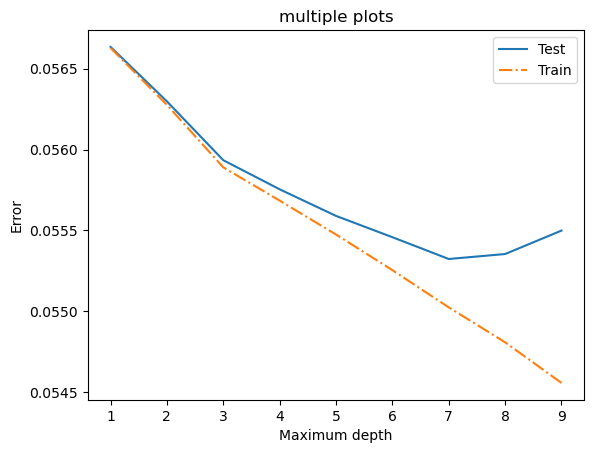

In [ ]:
start_value = 1
end_value = 10
index = 1
x_graph = list(range(start_value, end_value,index))
y_graph_test = []
y_graph_train = []

for parameter in range(start_value,end_value,index):
    model = DecisionTreeRegressor(max_depth=parameter, min_samples_leaf= 10)

    results = cross_validate(X=X_new,y=y, estimator=model, n_jobs=-1, scoring="neg_mean_squared_error", return_train_score=True)

    train_score = abs(np.mean(results["train_score"]))
    test_score = abs(np.mean(results["test_score"]))


    y_graph_test.append(test_score)
    y_graph_train.append(train_score)

plt.plot(x_graph, y_graph_test, label ='Test')
plt.plot(x_graph, y_graph_train, '-.', label ='Train')

plt.xlabel("Maximum depth")
plt.ylabel("Error")
plt.legend()
plt.title('multiple plots')
plt.show()

# Maximum depth is going to be 7

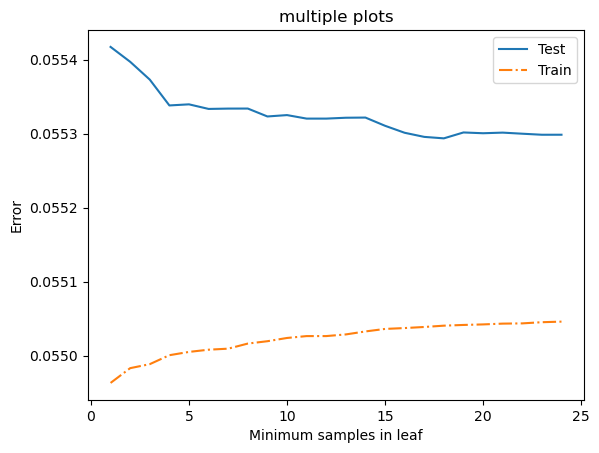

In [ ]:
start_value = 1
end_value = 25
index = 1
x_graph = list(range(start_value, end_value,index))
y_graph_test = []
y_graph_train = []

for parameter in range(start_value,end_value,index):
    model = DecisionTreeRegressor(max_depth=7, min_samples_leaf= parameter)

    results = cross_validate(X=X_new,y=y, estimator=model, n_jobs=-1, scoring="neg_mean_squared_error", return_train_score=True)

    train_score = abs(np.mean(results["train_score"]))
    test_score = abs(np.mean(results["test_score"]))


    y_graph_test.append(test_score)
    y_graph_train.append(train_score)

plt.plot(x_graph, y_graph_test, label ='Test')
plt.plot(x_graph, y_graph_train, '-.', label ='Train')

plt.xlabel("Minimum samples in leaf")
plt.ylabel("Error")
plt.legend()
plt.title('multiple plots')
plt.show()

# Minimum number of samples in leaf 5

In [194]:
from sklearn.metrics import r2_score
import numpy as np

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_new)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    bag_scores = []

    for b in range(n_bags):
        boot_idx = stratified_bootstrap_indices(
            y_train.values,
            n_samples=len(train_idx),
            min_positive_frac=0.04,
            random_state=42 + b
        )

        X_boot = X_train.iloc[boot_idx]
        y_boot = y_train.iloc[boot_idx]

        model = DecisionTreeRegressor(
            max_depth=7,
            min_samples_leaf=5,
            random_state=42
        )

        model.fit(X_boot, y_boot)

        # 🔹 R-squared on validation fold
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)
        bag_scores.append(r2)

    # Average over bags for this fold
    fold_scores.append(np.mean(bag_scores))

# Final CV R²
print(f"CV R²: {np.mean(fold_scores):.4f}")


CV R²: 0.0234


In [ ]:
good_model = DecisionTreeRegressor(max_depth=7,min_samples_leaf=5,random_state=42)

cross_validate(X=X_new, y=y,n_jobs=-1, estimator=good_model, scoring="r2")

{'fit_time': array([3.63873744, 3.54259253, 3.59478354, 3.65085816, 3.60576725]),
 'score_time': array([0.03404117, 0.03515601, 0.034096  , 0.03943348, 0.03691387]),
 'test_score': array([0.02897312, 0.02956591, 0.03024217, 0.02952498, 0.03093177])}